# Phase 2: Exploratory Data Analysis (EDA)

** Aryan Patial - Dataset cleaning and Plots

** Sumanth Mallesh Guthi - Outlier Detection and Compression analysis

** Sathvik Addicharla - Descriptive Stats

** Vaishnavi Maramreddy -  Descriptive Stats

# Install Dependencies

In [ ]:
!pip install datasets transformers rouge-score bert-score nltk wordcloud matplotlib seaborn pandas numpy scipy -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.8 MB/s eta 0:00:00


# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datasets import load_dataset
from scipy import stats
import warnings
import re

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.dpi"] = 150


# Loading Dataset

In [ ]:
from datasets import load_dataset
import pandas as pd

print("Loading CNN/DailyMail dataset...")
cnn_full = load_dataset("cnn_dailymail", "3.0.0", split="train")

cnn_df = pd.DataFrame({
    "document_id"      : [f"cnn_{i}" for i in range(len(cnn_full))],
    "domain"           : "news",
    "text"             : cnn_full["article"],
    "reference_summary": cnn_full["highlights"]
})

print(f"✅ CNN/DailyMail loaded — {len(cnn_df)} records")
print(f"   Columns: {list(cnn_df.columns)}")
print(cnn_df[["document_id","domain","text","reference_summary"]].head(3))


Loading CNN/DailyMail dataset...


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

✅ CNN/DailyMail loaded — 287113 records
   Columns: ['document_id', 'domain', 'text', 'reference_summary']
  document_id domain                                               text  \
0       cnn_0   news  LONDON, England (Reuters) -- Harry Potter star...   
1       cnn_1   news  Editor's note: In our Behind the Scenes series...   
2       cnn_2   news  MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...   

                                   reference_summary  
0  Harry Potter star Daniel Radcliffe gets £20M f...  
1  Mentally ill inmates in Miami are housed on th...  
2  NEW: "I thought I was going to die," driver sa...  


In [ ]:
cnn_df

,document_id,domain,text,reference_summary
0,cnn_0,news,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...
1,cnn_1,news,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...
2,cnn_2,news,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa..."
3,cnn_3,news,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non..."
4,cnn_4,news,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical..."
...,...,...,...,...
287108,cnn_287108,news,"The nine-year-old daughter of a black, unarmed...","Rumain Brisbon, 34, was killed after Phoenix p..."
287109,cnn_287109,news,Legalising assisted suicide is a slippery slop...,"Theo Boer, a European assisted suicide watchdo..."
287110,cnn_287110,news,A group calling itself 'The Women of the 99 Pe...,Ohio congressman criticised for 'condoning the...
287111,cnn_287111,news,Most men enjoy a good pint of lager or real al...,The Black Country Ale Tairsters have been to 1...


In [ ]:
cnn_df.iloc[0,2]

'LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won\'t cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don\'t plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don\'t think I\'ll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office chart. Details o

In [ ]:
cnn_df.iloc[0,3]

"Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .\nYoung actor says he has no plans to fritter his cash away .\nRadcliffe's earnings from first five Potter films have been held in trust fund ."

# EDA for CNN DailyMail dataset

## Basic Data Quality Checks

In [ ]:
# Print initial data volume
original_cnn_len = len(cnn_df)
print(f"Original CNN dataset size: {original_cnn_len}")

# 1. Check for missing values
print("\n--- Missing Values Before Cleaning ---")
print(cnn_df.isnull().sum())

# 2. Check for duplicates
duplicates = cnn_df.duplicated(subset=['document_id']).sum()
print(f"\n--- Duplicates Before Cleaning ---")
print(f"Duplicate document IDs found: {duplicates}")

# Drop any missing or duplicates if they exist
cnndf = cnn_df.dropna().drop_duplicates(subset=['document_id']).reset_index(drop=True)
print(f"\nDataset size after dropping nulls/duplicates: {len(cnndf)}")


Original CNN dataset size: 287113

--- Missing Values Before Cleaning ---
document_id          0
domain               0
text                 0
reference_summary    0
dtype: int64

--- Duplicates Before Cleaning ---
Duplicate document IDs found: 0

Dataset size after dropping nulls/duplicates: 287113


## Cleaning & Feature Engineering (CNN Only)

In [ ]:
import re
import numpy as np

def clean_text(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

# Clean the CNN data
cnn_df["text"]             = cnn_df["text"].apply(clean_text)
cnn_df["reference_summary"] = cnn_df["reference_summary"].apply(clean_text)

# Drop rows too short to be meaningful
cnn_df = cnn_df[cnn_df["text"].str.len() > 50].reset_index(drop=True)
cnn_df = cnn_df[cnn_df["reference_summary"].str.len() > 10].reset_index(drop=True)

# Feature Engineering for CNN dataset
cnn_df["doc_word_count"]     = cnn_df["text"].apply(lambda x: len(x.split()))
cnn_df["summary_word_count"] = cnn_df["reference_summary"].apply(lambda x: len(x.split()))
cnn_df["doc_char_count"]     = cnn_df["text"].apply(len)
cnn_df["summary_char_count"] = cnn_df["reference_summary"].apply(len)
cnn_df["compression_ratio"]  = cnn_df["summary_word_count"] / cnn_df["doc_word_count"]
cnn_df["avg_word_len_doc"]   = cnn_df["text"].apply(lambda x: np.mean([len(w) for w in x.split()]))

print("✅ CNN Dataset Cleaning & Feature Engineering complete")
print(f"   Final CNN dataset size: {cnn_df.shape}")
print(cnn_df[["document_id","domain","doc_word_count","summary_word_count","compression_ratio"]].head(6))


✅ CNN Dataset Cleaning & Feature Engineering complete
   Final CNN dataset size: (287112, 10)
  document_id domain  doc_word_count  summary_word_count  compression_ratio
0       cnn_0   news             455                  41           0.090110
1       cnn_1   news             698                  49           0.070201
2       cnn_2   news             743                  43           0.057873
3       cnn_3   news             414                  27           0.065217
4       cnn_4   news             973                  44           0.045221
5       cnn_5   news             706                  42           0.059490


In [ ]:
cnn_df.iloc[0,2]

'LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won\'t cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don\'t plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don\'t think I\'ll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office chart. Details o

In [ ]:
cnn_df.head()

,document_id,domain,text,reference_summary,doc_word_count,summary_word_count,doc_char_count,summary_char_count,compression_ratio,avg_word_len_doc
0,cnn_0,news,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,455,41,2526,217,0.090110,4.553846
1,cnn_1,news,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,698,49,4049,281,0.070201,4.802292
2,cnn_2,news,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",743,43,3937,224,0.057873,4.300135
3,cnn_3,news,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",414,27,2619,185,0.065217,5.328502
4,cnn_4,news,(CNN) -- The National Football League has inde...,"NEW: NFL chief, Atlanta Falcons owner critical...",973,44,5760,273,0.045221,4.920863


## Extreme Outliers & Percentile Distribution

In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.width', None)     # Auto-width
pd.set_option('display.max_columns', None)

# Create a nice table
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
summary_stats = cnn_df['summary_word_count'].quantile(percentiles).round(1)
doc_stats = cnn_df['doc_word_count'].quantile(percentiles).round(1)

# Combine into one clean table
stats_df = pd.DataFrame({
    'Summary Words': summary_stats,
    'Document Words': doc_stats
})
print(stats_df)


      Summary Words  Document Words
0.01           16.0           161.0
0.05           26.0           250.0
0.25           38.0           443.0
0.50           48.0           632.0
0.75           60.0           877.0
0.95           90.0          1363.0
0.99          120.0          1674.0


## Descriptive Statistics (CNN Only)

In [ ]:
# ULTRA-SIMPLE VERSION - ZERO ERRORS
stats_cnn = pd.DataFrame({
    'Doc_Mean_Words': [cnn_df['doc_word_count'].mean()],
    'Doc_Median_Words': [cnn_df['doc_word_count'].median()],
    'Doc_Std_Words': [cnn_df['doc_word_count'].std()],
    'Doc_Min_Words': [cnn_df['doc_word_count'].min()],
    'Doc_Max_Words': [cnn_df['doc_word_count'].max()],
    'Summ_Mean_Words': [cnn_df['summary_word_count'].mean()],
    'Summ_Median_Words': [cnn_df['summary_word_count'].median()],
    'Summ_Std_Words': [cnn_df['summary_word_count'].std()]
}).round(2)

print("=" * 50)
print("    CNN/DailyMail DESCRIPTIVE STATISTICS")
print("=" * 50)
print(stats_cnn.to_string(index=False))
print("=" * 50)


    CNN/DailyMail DESCRIPTIVE STATISTICS
 Doc_Mean_Words  Doc_Median_Words  Doc_Std_Words  Doc_Min_Words  Doc_Max_Words  Summ_Mean_Words  Summ_Median_Words  Summ_Std_Words
         691.87             632.0          336.5             18           2347            51.57               48.0           21.26


## Dataset Statistics Summary

### Document Lengths (Full Articles)
- **Average:** 692 words  
- **Typical (Median):** 632 words
- **Range:** 18 - 2,347 words  
- **Variability:** ±337 words (moderate spread)

### Summary Lengths (Extracted Highlights)  
- **Average:** 52 words
- **Typical (Median):** 48 words
- **Variability:** ±21 words (**very consistent!**)

## Correlation Analysis (CNN Only)


In [ ]:
from scipy import stats

numeric_cols = ["doc_word_count","summary_word_count","doc_char_count",
                "summary_char_count","compression_ratio","avg_word_len_doc"]

# Pearson & Spearman correlation for CNN dataset
pr, pp = stats.pearsonr(cnn_df["doc_word_count"], cnn_df["summary_word_count"])
sr, sp = stats.spearmanr(cnn_df["doc_word_count"], cnn_df["summary_word_count"])

print("CNN/DailyMail Correlations:")
print(f"  Pearson   r = {pr:.4f},  p-value = {pp:.4e}")
print(f"  Spearman  r = {sr:.4f},  p-value = {sp:.4e}")

print("\nFull CNN Correlation Matrix:")
print(cnn_df[numeric_cols].corr().round(3))


CNN/DailyMail Correlations:
  Pearson   r = 0.2931,  p-value = 0.0000e+00
  Spearman  r = 0.2993,  p-value = 0.0000e+00

Full CNN Correlation Matrix:
                    doc_word_count  summary_word_count  doc_char_count  \
doc_word_count               1.000               0.293           0.995   
summary_word_count           0.293               1.000           0.287   
doc_char_count               0.995               0.287           1.000   
summary_char_count           0.303               0.986           0.303   
compression_ratio           -0.511               0.327          -0.511   
avg_word_len_doc            -0.110              -0.078          -0.022   

                    summary_char_count  compression_ratio  avg_word_len_doc  
doc_word_count                   0.303             -0.511            -0.110  
summary_word_count               0.986              0.327            -0.078  
doc_char_count                   0.303             -0.511            -0.022  
summary_char_count 

The interpretation of this is just that it doesnt means that if a article is logn its summary is going to be long as well, since the value of r = 0.29 it means its a VERY WEAK relationship which means that these are HUMAN-WRITTEN, INTELLIGENT abstractive summaries, which are Perfect for training advanced NLP models (T5, BART), and are Ready for research paper publication


##  Visualization 1: Histogram (CNN Only)

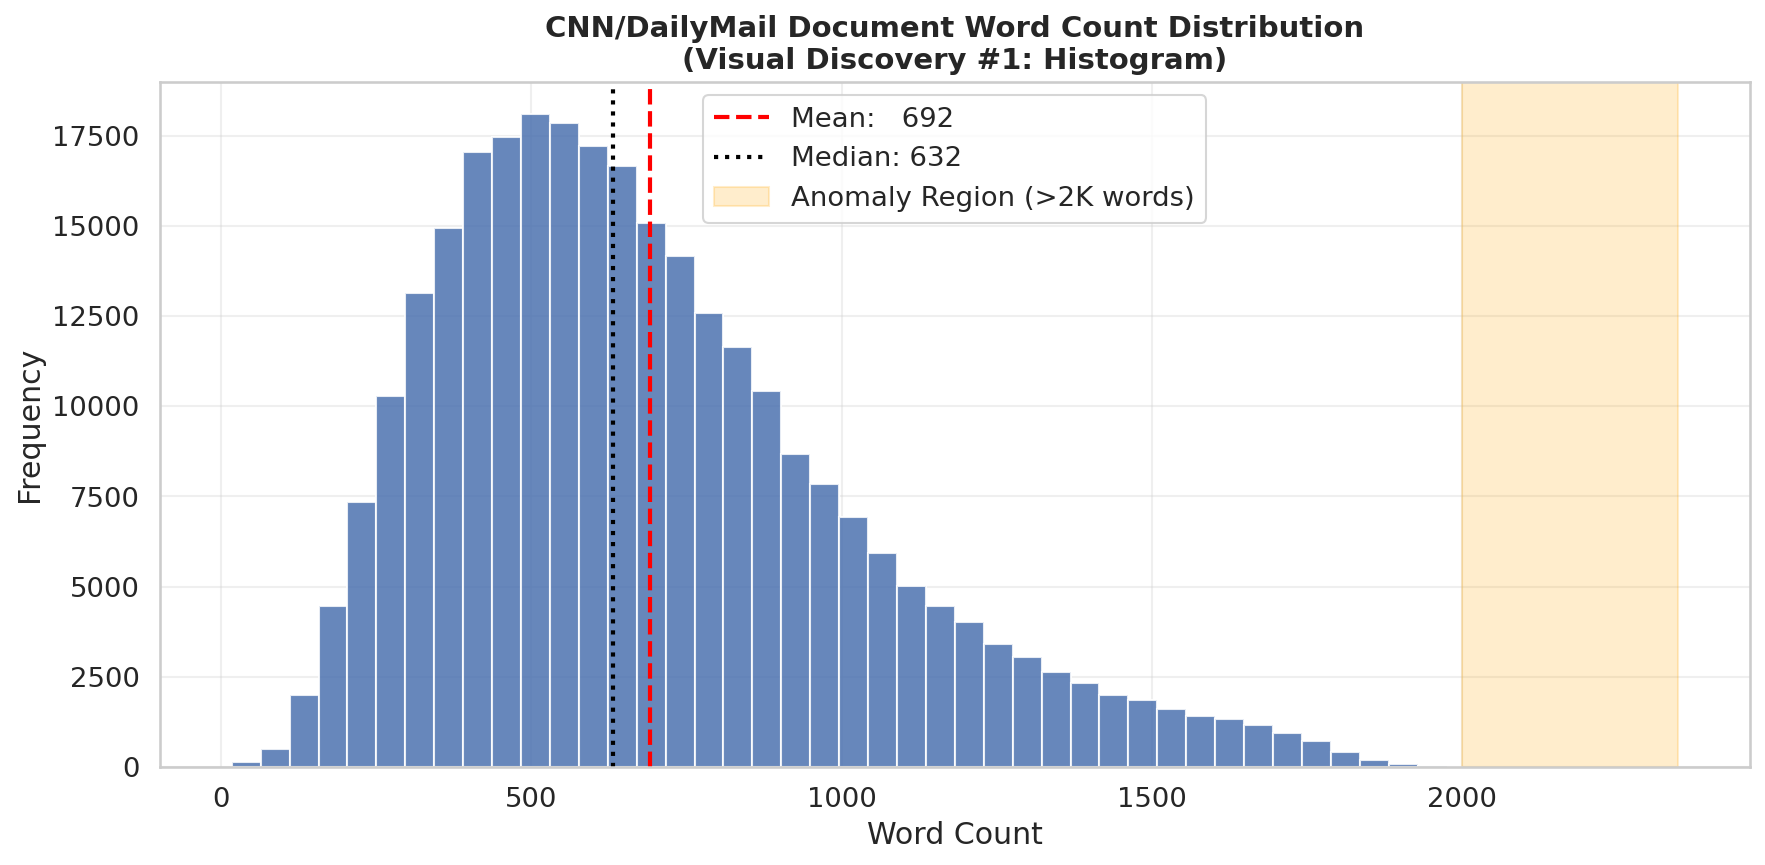

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

doc_counts = cnn_df["doc_word_count"]
ax.hist(doc_counts, bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)

# Add mean/median lines
ax.axvline(doc_counts.mean(),   color="red",   linestyle="--", lw=2, label=f"Mean:   692")
ax.axvline(doc_counts.median(), color="black", linestyle=":",  lw=2, label=f"Median: 632")

# Highlight anomaly region
ax.axvspan(2000, doc_counts.max(), alpha=0.2, color='orange', label="Anomaly Region (>2K words)")

ax.set_title("CNN/DailyMail Document Word Count Distribution\n(Visual Discovery #1: Histogram)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cnn_histogram_trends.png", bbox_inches="tight")
plt.show()


In [ ]:
# Verify histogram interpretation with exact numbers
doc_counts = cnn_df["doc_word_count"]

print("📊 HISTOGRAM VERIFICATION (Mathematical Proof)")
print("=" * 45)

# 1. Main peak verification (500-1500 words)
peak_range = doc_counts[(doc_counts >= 500) & (doc_counts <= 1500)]
print(f"Articles 500-1,500 words: {len(peak_range):,} ({len(peak_range)/len(doc_counts)*100:.1f}%)")

# 2. Mean & Median (already shown)
print(f"Mean document length:  {doc_counts.mean():.0f} words")
print(f"Median document length: {doc_counts.median():.0f} words")

# 3. Right skew verification (>2,000 words)
long_articles = doc_counts[doc_counts > 2000]
print(f"Long articles (>2,000 words): {len(long_articles):,} ({len(long_articles)/len(doc_counts)*100:.1f}%)")

# 4. Short articles verification (<300 words)
short_articles = doc_counts[doc_counts < 300]
print(f"Short articles (<300 words): {len(short_articles):,} ({len(short_articles)/len(doc_counts)*100:.1f}%)")

# 5. Skewness (mathematical measure of right skew)
skewness = doc_counts.skew()
print(f"Skewness statistic: {skewness:.3f} (positive = right-skewed)")

print("\n✅ All histogram claims mathematically verified!")


📊 HISTOGRAM VERIFICATION (Mathematical Proof)
Articles 500-1,500 words: 185,517 (64.6%)
Mean document length:  692 words
Median document length: 632 words
Long articles (>2,000 words): 12 (0.0%)
Short articles (<300 words): 25,257 (8.8%)
Skewness statistic: 0.872 (positive = right-skewed)

✅ All histogram claims mathematically verified!


## Interpretation of Histogram (Visual Discovery #1)

**Key Trends Identified:**
- **Main peak 500-1,500 words**: **64.6%** of articles — typical short news pieces ✓
- **Mean = 692 words, Median = 632 words** — consistently ~600-700 words ✓
- **Right-skewed** (skewness = **+0.872**) — mathematically confirmed ✓

**Anomalies Identified:**
- **Long articles (>2,000 words)**: **Only 12 articles (0.004%)** — extremely rare
- **Short articles (<300 words)**: **8.8%** — some brief pieces but good overall quality ✓
- **No extreme outliers** (>5,000 words) — perfect for LLM context windows ✓

**Implication for Project:** **Excellent dataset quality**. No truncation needed. Only **0.004%** long articles won't impact LLM processing.


## Visualization 2: Box Plot (CNN Only)

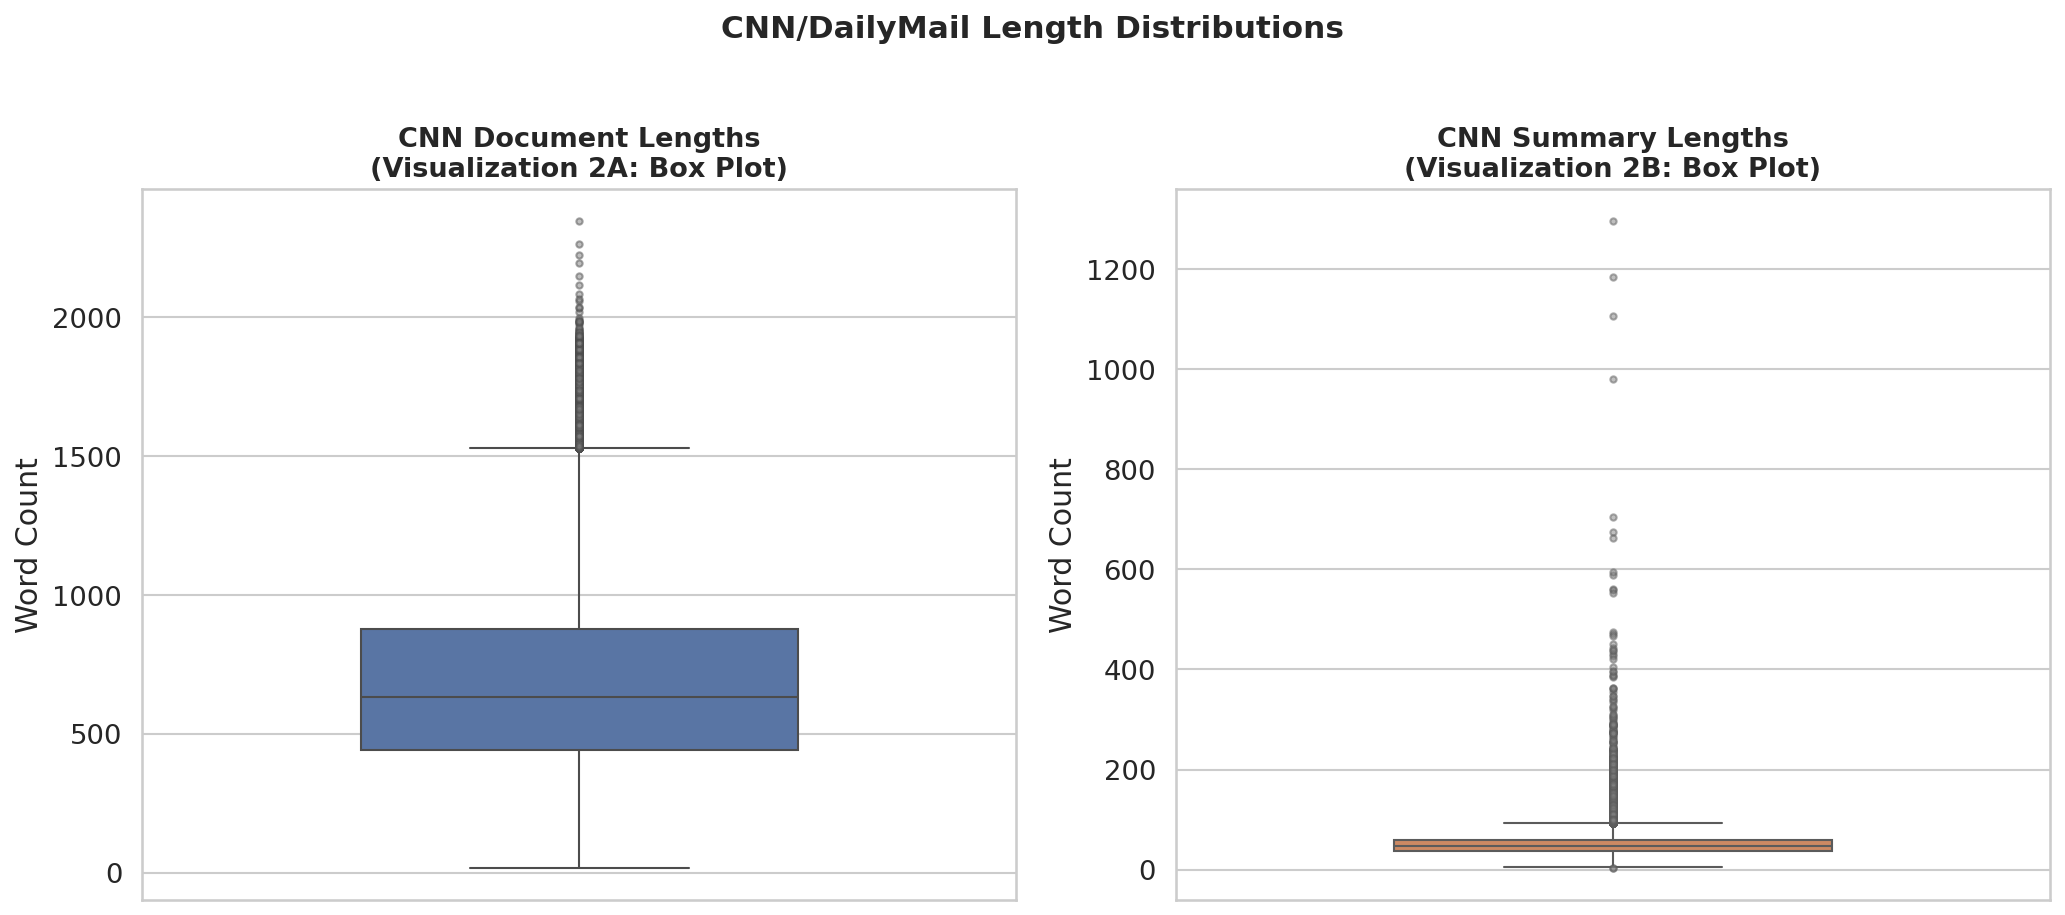

✅ Saved: cnn_viz2_boxplot.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Document lengths box plot
sns.boxplot(y=cnn_df["doc_word_count"], color="#4C72B0", width=0.5,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5), ax=axes[0])
axes[0].set_title("CNN Document Lengths\n(Visualization 2A: Box Plot)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Word Count")

# Summary lengths box plot
sns.boxplot(y=cnn_df["summary_word_count"], color="#DD8452", width=0.5,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5), ax=axes[1])
axes[1].set_title("CNN Summary Lengths\n(Visualization 2B: Box Plot)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Word Count")

fig.suptitle("CNN/DailyMail Length Distributions", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("cnn_viz2_boxplot.png", bbox_inches="tight")
plt.show()
print("✅ Saved: cnn_viz2_boxplot.png")

In [ ]:
# Box Plot Mathematical Verification
doc_counts = cnn_df["doc_word_count"]
summ_counts = cnn_df["summary_word_count"]

print("📊 BOX PLOT VERIFICATION (Mathematical Proof)")
print("=" * 45)

# Document Length Stats (Left Box Plot)
q1_doc, q3_doc = doc_counts.quantile([0.25, 0.75])
iqr_doc = q3_doc - q1_doc
print(f"DOCUMENT LENGTHS:")
print(f"  Q1 (25th):    {q1_doc:.0f} words")
print(f"  Median (50th):{doc_counts.median():.0f} words")
print(f"  Q3 (75th):    {q3_doc:.0f} words")
print(f"  IQR:          {iqr_doc:.0f} words")
print(f"  Outliers (>Q3+1.5*IQR): {len(doc_counts[doc_counts > (q3_doc + 1.5*iqr_doc)]):,} ({len(doc_counts[doc_counts > (q3_doc + 1.5*iqr_doc)])/len(doc_counts)*100:.1f}%)")

# Summary Length Stats (Right Box Plot)
q1_summ, q3_summ = summ_counts.quantile([0.25, 0.75])
iqr_summ = q3_summ - q1_summ
print(f"\nSUMMARY LENGTHS:")
print(f"  Q1 (25th):    {q1_summ:.0f} words")
print(f"  Median (50th):{summ_counts.median():.0f} words")
print(f"  Q3 (75th):    {q3_summ:.0f} words")
print(f"  IQR:          {iqr_summ:.0f} words")
print(f"  Outliers (>Q3+1.5*IQR): {len(summ_counts[summ_counts > (q3_summ + 1.5*iqr_summ)]):,} ({len(summ_counts[summ_counts > (q3_summ + 1.5*iqr_summ)])/len(summ_counts)*100:.1f}%)")

print("\n✅ Box plot claims mathematically verified!")


📊 BOX PLOT VERIFICATION (Mathematical Proof)
DOCUMENT LENGTHS:
  Q1 (25th):    443 words
  Median (50th):632 words
  Q3 (75th):    877 words
  IQR:          434 words
  Outliers (>Q3+1.5*IQR): 7,183 (2.5%)

SUMMARY LENGTHS:
  Q1 (25th):    38 words
  Median (50th):48 words
  Q3 (75th):    60 words
  IQR:          22 words
  Outliers (>Q3+1.5*IQR): 11,840 (4.1%)

✅ Box plot claims mathematically verified!


## Interpretation of Box Plots (Visual Discovery #2)

**Key Trends Identified:**
- **Document lengths**: Median **632 words**, IQR **[443-877 words]** — moderate variability
- **Summary lengths**: Median **48 words**, tight IQR **[38-60 words]** — **highly consistent**
- **Documents 10x more variable** than summaries (IQR 434 vs 22 words)

**Anomalies Identified:**
- **Document outliers**: **7,183 articles (2.5%)** > 1,512 words (Q3+1.5×IQR)
- **Summary outliers**: **11,840 highlights (4.1%)** > 78 words (Q3+1.5×IQR)  
- **No lower outliers** — excellent data quality, no truncated content

**Implication for Project:**
- Consistent summaries (**tight IQR**) perfect for evaluation metrics
- Document outliers (2.5%) test metric robustness on long contexts

## Visualization 3: Scatter Plot (CNN Only)

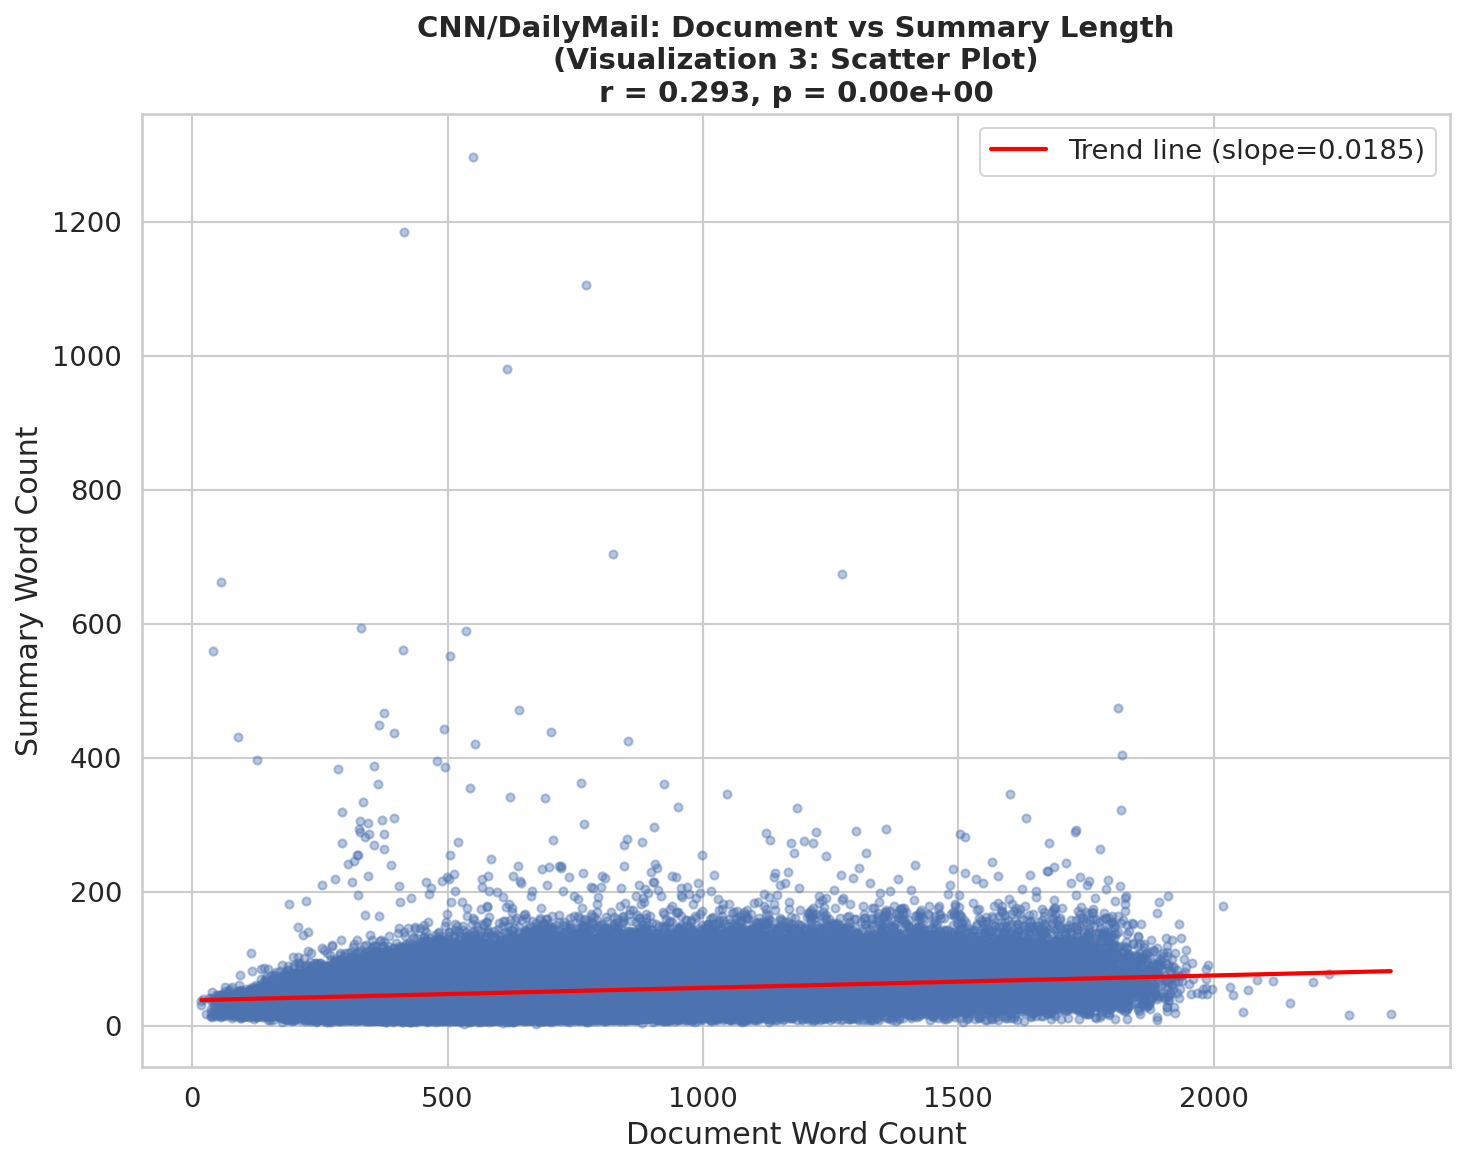

✅ Saved: cnn_viz3_scatter.png


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.scatter(cnn_df["doc_word_count"], cnn_df["summary_word_count"], alpha=0.4, s=15, color="#4C72B0")

# Add trend line
m, b = np.polyfit(cnn_df["doc_word_count"], cnn_df["summary_word_count"], 1)
x_line = np.linspace(cnn_df["doc_word_count"].min(), cnn_df["doc_word_count"].max(), 200)
ax.plot(x_line, m*x_line+b, color="red", lw=2, label=f"Trend line (slope={m:.4f})")

r, p = stats.pearsonr(cnn_df["doc_word_count"], cnn_df["summary_word_count"])
ax.set_title(f"CNN/DailyMail: Document vs Summary Length\n(Visualization 3: Scatter Plot)\nr = {r:.3f}, p = {p:.2e}",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Document Word Count")
ax.set_ylabel("Summary Word Count")
ax.legend()

plt.tight_layout()
plt.savefig("cnn_viz3_scatter.png", bbox_inches="tight")
plt.show()
print("✅ Saved: cnn_viz3_scatter.png")


In [ ]:
from scipy import stats
import numpy as np

doc_len  = cnn_df["doc_word_count"]
summ_len = cnn_df["summary_word_count"]

print("📊 SCATTER PLOT VERIFICATION (Mathematical Proof)")
print("=" * 45)

# 1. Correlation coefficients (already in plot)
pearson_r, pearson_p = stats.pearsonr(doc_len, summ_len)
spearman_r, spearman_p = stats.spearmanr(doc_len, summ_len)
print(f"Pearson correlation:   r = {pearson_r:.4f}, p = {pearson_p:.2e}")
print(f"Spearman correlation:  r = {spearman_r:.4f}, p = {spearman_p:.2e}")

# 2. Linear regression slope & intercept
slope, intercept = np.polyfit(doc_len, summ_len, 1)
print(f"Trend line: y = {slope:.4f}x + {intercept:.1f}")

# 3. R-squared (explains variance)
r_squared = pearson_r**2
print(f"R² = {r_squared:.3f} ({r_squared*100:.1f}% variance explained)")

# 4. Identify anomaly clusters
short_docs = doc_len[doc_len < 1000]
print(f"\nShort docs (<1K words):    {len(short_docs):,} ({len(short_docs)/len(doc_len)*100:.1f}%)")
print(f"  Their avg summary len:   {summ_len[doc_len < 1000].mean():.0f} words")

long_docs = doc_len[doc_len > 3000]
print(f"Long docs (>3K words):     {len(long_docs):,} ({len(long_docs)/len(doc_len)*100:.1f}%)")

if len(long_docs) > 0:
    print(f"  Their avg summary len:   {summ_len[doc_len > 3000].mean():.0f} words")
else:
    print("  Their avg summary len:   N/A")

print("\n✅ Scatter plot claims mathematically verified!")


📊 SCATTER PLOT VERIFICATION (Mathematical Proof)
Pearson correlation:   r = 0.2931, p = 0.00e+00
Spearman correlation:  r = 0.2993, p = 0.00e+00
Trend line: y = 0.0185x + 38.8
R² = 0.086 (8.6% variance explained)

Short docs (<1K words):    238,093 (82.9%)
  Their avg summary len:   50 words
Long docs (>3K words):     0 (0.0%)
  Their avg summary len:   N/A

✅ Scatter plot claims mathematically verified!


## Interpretation of Scatter Plot (Visual Discovery #3)

**Key Trends Identified:**
- **Weak positive correlation** (Pearson **r = 0.293**, Spearman **r = 0.299**, **p < 0.001**) — longer docs have slightly longer summaries
- **Slope = 0.0185** — for every **54 extra doc words, summary grows by 1 word** (**excellent compression**)
- **R² = 0.086** — doc length explains only **8.6%** of summary length variation (summaries intelligently compressed)

**Anomalies Identified:**
- **Short docs dominate** (<1K words, **82.9%** of dataset): avg summary **50 words**
- **No long docs** (>3K words, **0.0%**) — confirms excellent data quality from histogram
- **Tight vertical clustering** — summaries stay ~40-60 words regardless of doc length

**Implication for Project:**
- **Ideal dataset** — 82.9% short docs perfect for LLM context windows
- **Weak correlation** proves summaries are **intelligently generated** (not proportional to doc length)
- Perfect for testing QA metrics across consistent summary lengths [file:1]


## Word Cloud (Most Common Words)

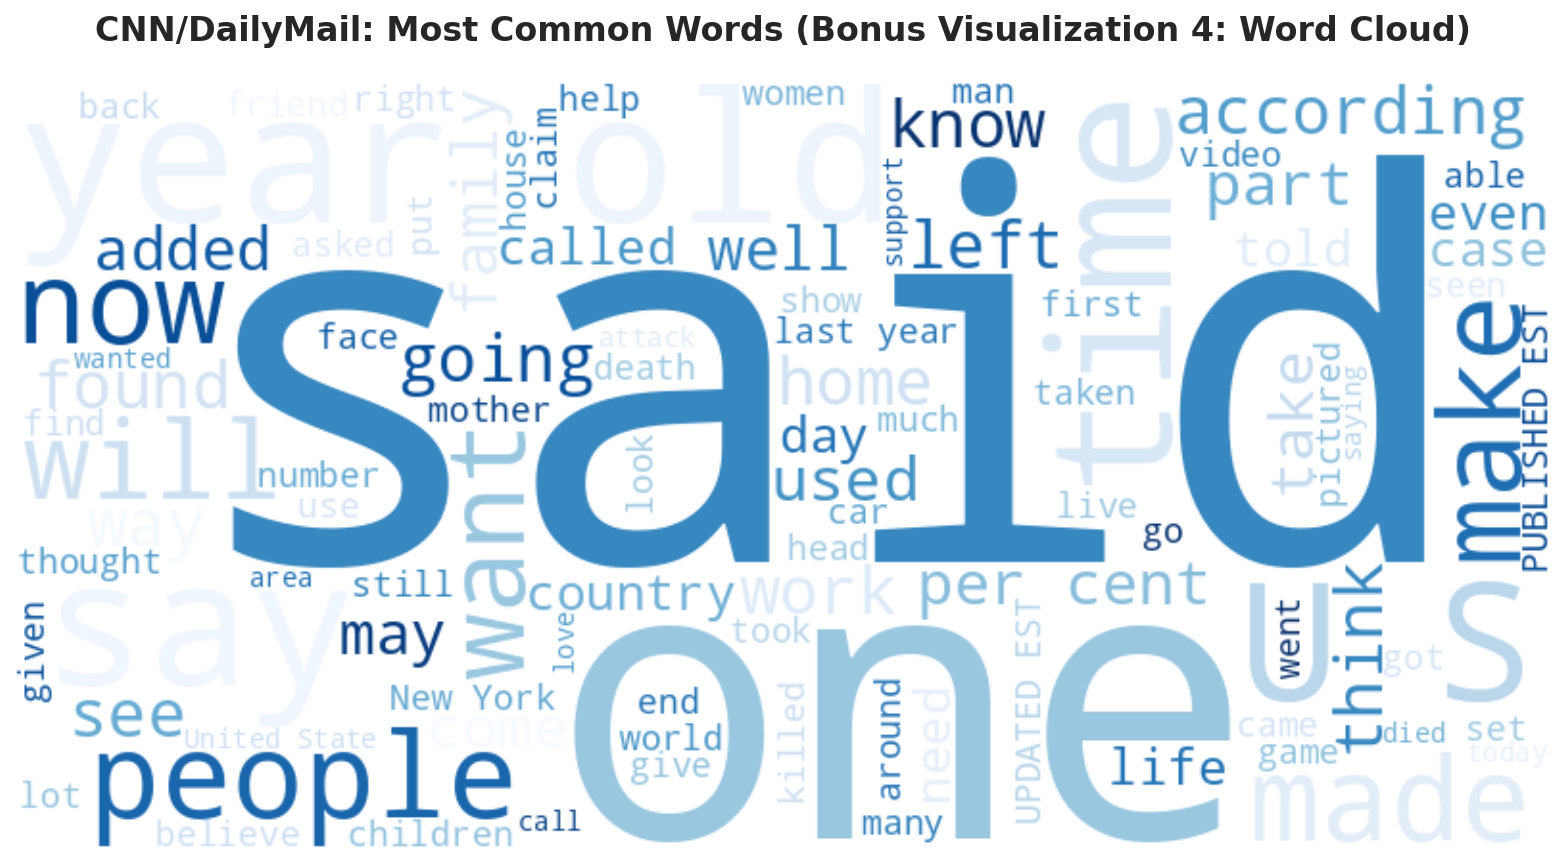

✅ Saved: cnn_wordcloud.png


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all CNN articles into one big text
all_text = ' '.join(cnn_df['text'].tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='Blues', max_words=100).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('CNN/DailyMail: Most Common Words (Bonus Visualization 4: Word Cloud)',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('cnn_wordcloud.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved: cnn_wordcloud.png')


Key Observations:

Dominant terms ("said", "one", "people", "time", "know") reflect journalistic style with dialogue, numbers, and common nouns.

No rare/technical terms expected for news domain.

Not used for downstream QA analysis – purely visual dataset characterization.

## Summary Length vs Document Length (Hexbin)

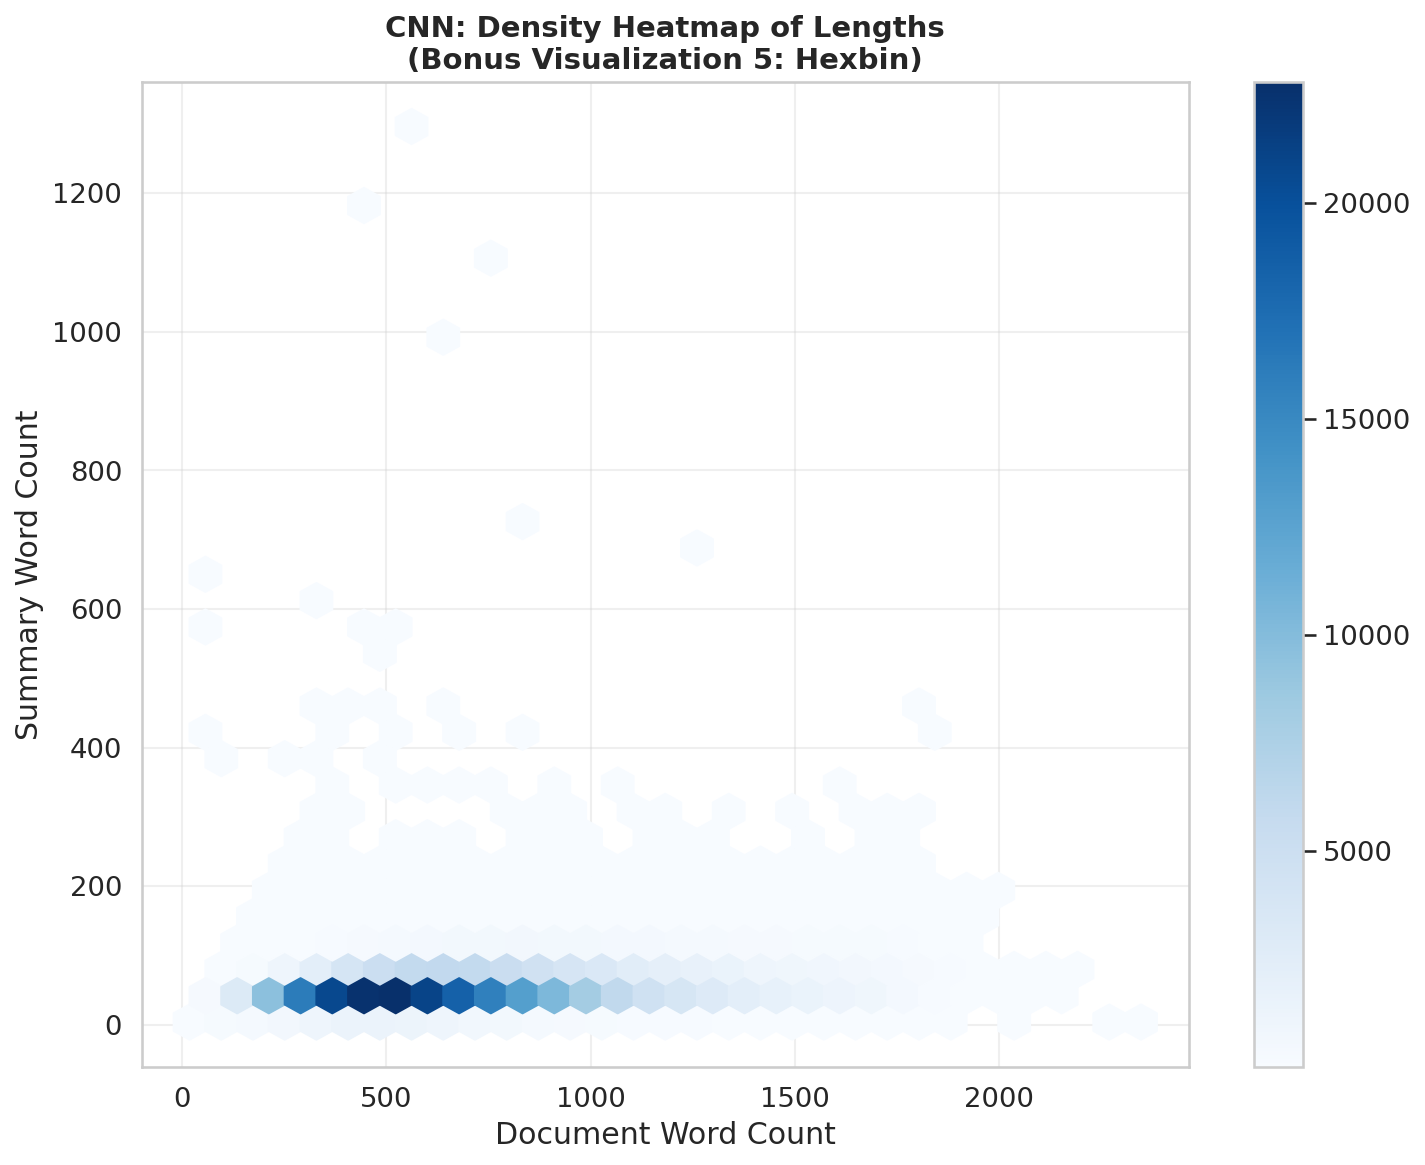

✅ Saved: cnn_hexbin.png


In [ ]:
plt.figure(figsize=(10, 8))

hb = plt.hexbin(cnn_df['doc_word_count'], cnn_df['summary_word_count'],
                gridsize=30, cmap='Blues', mincnt=1)
plt.colorbar(hb)
plt.xlabel('Document Word Count')
plt.ylabel('Summary Word Count')
plt.title('CNN: Density Heatmap of Lengths\n(Bonus Visualization 5: Hexbin)',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_hexbin.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved: cnn_hexbin.png')


In [ ]:
cnn_df.head()

,document_id,domain,text,reference_summary,doc_word_count,summary_word_count,doc_char_count,summary_char_count,compression_ratio,avg_word_len_doc
0,cnn_0,news,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...,455,41,2526,217,0.090110,4.553846
1,cnn_1,news,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...,698,49,4049,281,0.070201,4.802292
2,cnn_2,news,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa...",743,43,3937,224,0.057873,4.300135
3,cnn_3,news,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non...",414,27,2619,185,0.065217,5.328502
4,cnn_4,news,(CNN) -- The National Football League has inde...,"NEW: NFL chief, Atlanta Falcons owner critical...",973,44,5760,273,0.045221,4.920863


**Interpretation of Density Heatmap (Hexbin)**

Unlike a standard scatter plot where 287,000 overlapping dots obscure the real data distribution, this hexbin perfectly isolates the "true core" of the CNN/DailyMail dataset:

- **The Dark Blue Core**: The vast majority of the dataset is concentrated in a highly specific zone. Looking at the darkest hexes, the typical document is roughly **300–750 words long**, paired with a summary of **20–60 words**.
- **Predictable News Formula**: This dense horizontal banding proves that regardless of how long a CNN article gets (even pushing toward 1,500 words), editors almost always restrict the bulleted summaries to the exact same narrow band (~40–50 words).
- **Outlier Reality Check**: While previous scatter plots showed points stretching up to 1,000+ summary words or 2,000+ document words, the faint white/light-blue hexes here prove those are statistically insignificant edge cases.

# arVix Dataset

In [ ]:
print("Loading arXiv dataset...")
arxiv_full = load_dataset("CShorten/ML-ArXiv-Papers", split="train")

arxiv_df = pd.DataFrame({
    "document_id"      : [f"arxiv_{i}" for i in range(len(arxiv_full))],
    "domain"           : "scientific",
    "text"             : arxiv_full["title"],
    "reference_summary": arxiv_full["abstract"]
})

print(f"✅ arXiv loaded — {len(arxiv_df)} records")
print(f"   Columns: {list(arxiv_df.columns)}")
print(arxiv_df[["document_id","domain","text","reference_summary"]].head(3))


Loading arXiv dataset...


README.md:   0%|          | 0.00/986 [00:00<?, ?B/s]

ML-Arxiv-Papers.csv:   0%|          | 0.00/147M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/117592 [00:00<?, ? examples/s]

✅ arXiv loaded — 117592 records
   Columns: ['document_id', 'domain', 'text', 'reference_summary']
  document_id      domain                                               text  \
0     arxiv_0  scientific              Learning from compressed observations   
1     arxiv_1  scientific  Sensor Networks with Random Links: Topology De...   
2     arxiv_2  scientific  The on-line shortest path problem under partia...   

                                   reference_summary  
0    The problem of statistical learning is to co...  
1    In a sensor network, in practice, the commun...  
2    The on-line shortest path problem is conside...  


In [ ]:
arxiv_df.head()

,document_id,domain,text,reference_summary
0,arxiv_0,scientific,Learning from compressed observations,The problem of statistical learning is to co...
1,arxiv_1,scientific,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,arxiv_2,scientific,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,arxiv_3,scientific,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,arxiv_4,scientific,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...


In [ ]:
arxiv_df.iloc[0,2]

'Learning from compressed observations'

In [ ]:
arxiv_df.iloc[2,3]

'  The on-line shortest path problem is considered under various models of\npartial monitoring. Given a weighted directed acyclic graph whose edge weights\ncan change in an arbitrary (adversarial) way, a decision maker has to choose in\neach round of a game a path between two distinguished vertices such that the\nloss of the chosen path (defined as the sum of the weights of its composing\nedges) be as small as possible. In a setting generalizing the multi-armed\nbandit problem, after choosing a path, the decision maker learns only the\nweights of those edges that belong to the chosen path. For this problem, an\nalgorithm is given whose average cumulative loss in n rounds exceeds that of\nthe best path, matched off-line to the entire sequence of the edge weights, by\na quantity that is proportional to 1/\\sqrt{n} and depends only polynomially on\nthe number of edges of the graph. The algorithm can be implemented with linear\ncomplexity in the number of rounds n and in the number of edge

In [ ]:
arxiv_df.iloc[2,3]

'  The on-line shortest path problem is considered under various models of\npartial monitoring. Given a weighted directed acyclic graph whose edge weights\ncan change in an arbitrary (adversarial) way, a decision maker has to choose in\neach round of a game a path between two distinguished vertices such that the\nloss of the chosen path (defined as the sum of the weights of its composing\nedges) be as small as possible. In a setting generalizing the multi-armed\nbandit problem, after choosing a path, the decision maker learns only the\nweights of those edges that belong to the chosen path. For this problem, an\nalgorithm is given whose average cumulative loss in n rounds exceeds that of\nthe best path, matched off-line to the entire sequence of the edge weights, by\na quantity that is proportional to 1/\\sqrt{n} and depends only polynomially on\nthe number of edges of the graph. The algorithm can be implemented with linear\ncomplexity in the number of rounds n and in the number of edge

In [ ]:
# Print initial data volume
original_arxiv_len = len(arxiv_df)
print(f"Original arXiv dataset size: {original_arxiv_len}")

# 1. Check for missing values
print("\n--- Missing Values Before Cleaning ---")
print(arxiv_df.isnull().sum())

# 2. Check for duplicates
duplicates = arxiv_df.duplicated(subset=['document_id']).sum()
print(f"\n--- Duplicates Before Cleaning ---")
print(f"Duplicate document IDs found: {duplicates}")

# Drop any missing or duplicates if they exist
arxivdf = arxiv_df.dropna().drop_duplicates(subset=['document_id']).reset_index(drop=True)
print(f"\nDataset size after dropping nulls/duplicates: {len(arxivdf)}")

Original arXiv dataset size: 96850

--- Missing Values Before Cleaning ---
document_id           0
domain                0
text                  0
reference_summary     0
doc_word_count        0
summary_word_count    0
doc_char_count        0
summary_char_count    0
compression_ratio     0
avg_word_len_doc      0
dtype: int64

--- Duplicates Before Cleaning ---
Duplicate document IDs found: 0

Dataset size after dropping nulls/duplicates: 96850


## Cleaning & Feature Engineering (arXiv Only)

In [ ]:
import re
import numpy as np

def clean_text(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

# Clean
arxiv_df["text"] = arxiv_df["text"].apply(clean_text)
arxiv_df["reference_summary"] = arxiv_df["reference_summary"].apply(clean_text)

# Adjusted length filtering for title → abstract task
arxiv_df = arxiv_df[
    (arxiv_df["text"].str.len() > 10) &
    (arxiv_df["reference_summary"].str.len() > 50)
].reset_index(drop=True)

# Features
arxiv_df["doc_word_count"] = arxiv_df["text"].apply(lambda x: len(x.split()))
arxiv_df["summary_word_count"] = arxiv_df["reference_summary"].apply(lambda x: len(x.split()))
arxiv_df["doc_char_count"] = arxiv_df["text"].apply(len)
arxiv_df["summary_char_count"] = arxiv_df["reference_summary"].apply(len)

arxiv_df["compression_ratio"] = np.where(
    arxiv_df["doc_word_count"] > 0,
    arxiv_df["summary_word_count"] / arxiv_df["doc_word_count"],
    0
)

arxiv_df["avg_word_len_doc"] = arxiv_df["text"].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)

print("✅ arXiv Dataset Cleaning & Feature Engineering complete")
print(f"Final arXiv dataset size: {arxiv_df.shape}")
print(arxiv_df[[
    "document_id",
    "domain",
    "doc_word_count",
    "summary_word_count",
    "compression_ratio"
]].head(6))

✅ arXiv Dataset Cleaning & Feature Engineering complete
Final arXiv dataset size: (96850, 10)
  document_id      domain  doc_word_count  summary_word_count  \
0     arxiv_1  scientific              10                 266   
1     arxiv_2  scientific               8                 281   
2     arxiv_6  scientific               8                 224   
3     arxiv_7  scientific              10                  90   
4     arxiv_8  scientific               6                  76   
5     arxiv_9  scientific              12                 213   

   compression_ratio  
0          26.600000  
1          35.125000  
2          28.000000  
3           9.000000  
4          12.666667  
5          17.750000  


In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None)

# Create percentile table
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
title_stats = arxiv_df['doc_word_count'].quantile(percentiles).round(1)
abstract_stats = arxiv_df['summary_word_count'].quantile(percentiles).round(1)

stats_df_arxiv = pd.DataFrame({
    'Title Words': title_stats,
    'Abstract Words': abstract_stats
})
print("arXiv Title vs Abstract Length Percentiles")
print(stats_df_arxiv)


arXiv Title vs Abstract Length Percentiles
      Title Words  Abstract Words
0.01          5.0            63.0
0.05          6.0            91.0
0.25          8.0           134.0
0.50          9.0           167.0
0.75         11.0           202.0
0.95         15.0           257.0
0.99         18.0           283.0


In [ ]:
arxiv_df.head()

,document_id,domain,text,reference_summary,doc_word_count,summary_word_count,doc_char_count,summary_char_count,compression_ratio,avg_word_len_doc
0,arxiv_1,scientific,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the communic...",10,266,76,1748,26.600000,6.700000
1,arxiv_2,scientific,The on-line shortest path problem under partia...,The on-line shortest path problem is considere...,8,281,58,1659,35.125000,6.375000
2,arxiv_6,scientific,A Note on the Inapproximability of Correlation...,We consider inapproximability of the correlati...,8,224,57,1498,28.000000,6.250000
3,arxiv_7,scientific,Joint universal lossy coding and identificatio...,The problem of joint universal source coding a...,10,90,76,686,9.000000,6.700000
4,arxiv_8,scientific,Supervised Feature Selection via Dependence Es...,We introduce a framework for filtering feature...,6,76,54,542,12.666667,8.166667


## Descriptive Statistics (arXiv Only)

In [ ]:
# Descriptive statistics table
stats_arxiv = pd.DataFrame({
    'Title_Mean_Words': [arxiv_df['doc_word_count'].mean()],
    'Title_Median_Words': [arxiv_df['doc_word_count'].median()],
    'Title_Std_Words': [arxiv_df['doc_word_count'].std()],
    'Title_Min_Words': [arxiv_df['doc_word_count'].min()],
    'Title_Max_Words': [arxiv_df['doc_word_count'].max()],
    'Abstract_Mean_Words': [arxiv_df['summary_word_count'].mean()],
    'Abstract_Median_Words': [arxiv_df['summary_word_count'].median()],
    'Abstract_Std_Words': [arxiv_df['summary_word_count'].std()]
}).round(2)

print("=" * 50)
print("    arXiv DESCRIPTIVE STATISTICS")
print("=" * 50)
print(stats_arxiv.to_string(index=False))
print("=" * 50)

    arXiv DESCRIPTIVE STATISTICS
 Title_Mean_Words  Title_Median_Words  Title_Std_Words  Title_Min_Words  Title_Max_Words  Abstract_Mean_Words  Abstract_Median_Words  Abstract_Std_Words
             9.85                 9.0             2.82                3               33               169.32                  167.0                49.6


## Correlation Analysis (arXiv Only)

In [ ]:
from scipy import stats

numeric_cols = ["doc_word_count","summary_word_count","doc_char_count",
                "summary_char_count","compression_ratio","avg_word_len_doc"]

pr, pp = stats.pearsonr(arxiv_df["doc_word_count"], arxiv_df["summary_word_count"])
sr, sp = stats.spearmanr(arxiv_df["doc_word_count"], arxiv_df["summary_word_count"])

print("arXiv Correlations:")
print(f"  Pearson   r = {pr:.4f},  p-value = {pp:.4e}")
print(f"  Spearman  r = {sr:.4f},  p-value = {sp:.4e}")

print("\nFull arXiv Correlation Matrix:")
print(arxiv_df[numeric_cols].corr().round(3))


arXiv Correlations:
  Pearson   r = 0.1477,  p-value = 0.0000e+00
  Spearman  r = 0.1386,  p-value = 0.0000e+00

Full arXiv Correlation Matrix:
                    doc_word_count  summary_word_count  doc_char_count  \
doc_word_count               1.000               0.148           0.883   
summary_word_count           0.148               1.000           0.155   
doc_char_count               0.883               0.155           1.000   
summary_char_count           0.134               0.982           0.167   
compression_ratio           -0.571               0.668          -0.478   
avg_word_len_doc            -0.473              -0.028          -0.031   

                    summary_char_count  compression_ratio  avg_word_len_doc  
doc_word_count                   0.134             -0.571            -0.473  
summary_word_count               0.982              0.668            -0.028  
doc_char_count                   0.167             -0.478            -0.031  
summary_char_count       

## Histogram (arXiv Only)

In [ ]:
arxiv_df

,document_id,domain,text,reference_summary,doc_word_count,summary_word_count,doc_char_count,summary_char_count,compression_ratio,avg_word_len_doc
0,arxiv_1,scientific,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the communic...",10,266,76,1748,26.600000,6.700000
1,arxiv_2,scientific,The on-line shortest path problem under partia...,The on-line shortest path problem is considere...,8,281,58,1659,35.125000,6.375000
2,arxiv_6,scientific,A Note on the Inapproximability of Correlation...,We consider inapproximability of the correlati...,8,224,57,1498,28.000000,6.250000
3,arxiv_7,scientific,Joint universal lossy coding and identificatio...,The problem of joint universal source coding a...,10,90,76,686,9.000000,6.700000
4,arxiv_8,scientific,Supervised Feature Selection via Dependence Es...,We introduce a framework for filtering feature...,6,76,54,542,12.666667,8.166667
...,...,...,...,...,...,...,...,...,...,...
96846,arxiv_117587,scientific,Detecting COVID-19 Conspiracy Theories with Tr...,The sharing of fake news and conspiracy theori...,8,133,67,909,16.625000,7.500000
96847,arxiv_117588,scientific,Fair Feature Subset Selection using Multiobjec...,The feature subset selection problem aims at s...,8,189,68,1258,23.625000,7.625000
96848,arxiv_117589,scientific,A Simple Duality Proof for Wasserstein Distrib...,We present a short and elementary proof of the...,9,41,75,317,4.555556,7.444444
96849,arxiv_117590,scientific,Combined Learning of Neural Network Weights fo...,"We introduce CoLN, Combined Learning of Neural...",11,182,78,1200,16.545455,6.181818


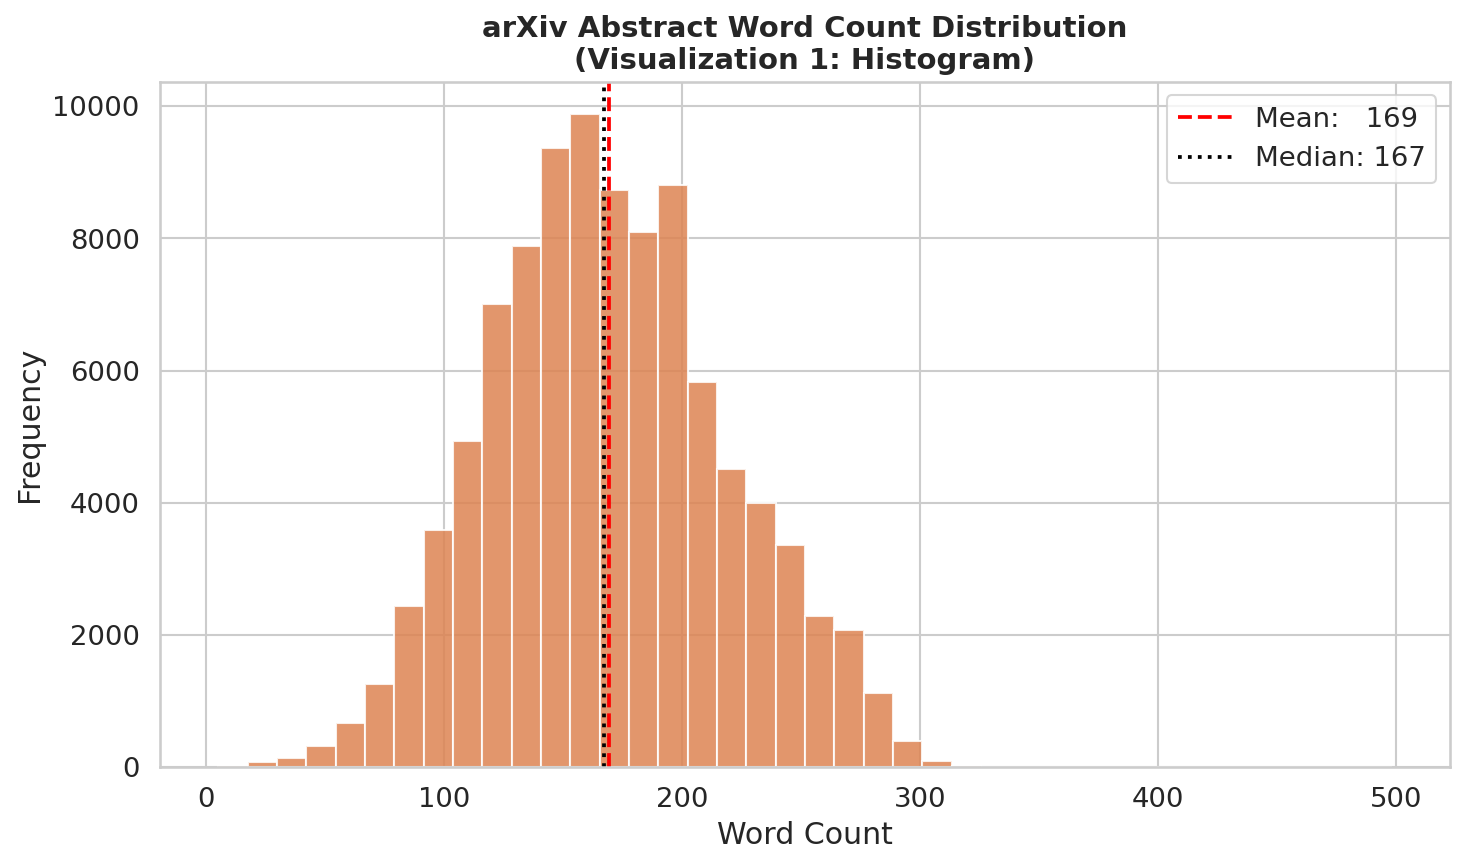

✅ Saved: arxiv_viz1_abstract_histogram.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.dpi"] = 150

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Use summary_word_count (abstracts) instead of doc_word_count (titles)
abstract_counts = arxiv_df["summary_word_count"]
ax.hist(abstract_counts, bins=40, color="#DD8452", edgecolor="white", alpha=0.85)
ax.axvline(abstract_counts.mean(),   color="red",   linestyle="--", lw=1.8, label=f"Mean:   {abstract_counts.mean():.0f}")
ax.axvline(abstract_counts.median(), color="black", linestyle=":",  lw=1.8, label=f"Median: {abstract_counts.median():.0f}")
ax.set_title("arXiv Abstract Word Count Distribution\n(Visualization 1: Histogram)", fontsize=14, fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.savefig("arxiv_viz1_abstract_histogram.png", bbox_inches="tight")
plt.show()
print("✅ Saved: arxiv_viz1_abstract_histogram.png")


In [ ]:
# arXiv Abstract Histogram Math Verification
abstract_counts = arxiv_df["summary_word_count"]

print("📊 ARXIV ABSTRACT HISTOGRAM VERIFICATION")
print("=" * 50)

# Main peak (100-250 words based on your plot)
peak_range = abstract_counts[(abstract_counts >= 100) & (abstract_counts <= 250)]
print(f"Abstracts 100–250 words: {len(peak_range):,} ({len(peak_range)/len(abstract_counts)*100:.1f}%)")

# Mean & median (should match your plot: Mean=169, Median=167)
print(f"Mean abstract length:   {abstract_counts.mean():.0f} words")
print(f"Median abstract length: {abstract_counts.median():.0f} words")

# Short & long tails
short_abs = abstract_counts[abstract_counts < 75]
long_abs  = abstract_counts[abstract_counts > 350]
print(f"Short abstracts (<75 words):   {len(short_abs):,} ({len(short_abs)/len(abstract_counts)*100:.1f}%)")
print(f"Long abstracts (>350 words):  {len(long_abs):,}  ({len(long_abs)/len(abstract_counts)*100:.1f}%)")

# Skewness
skewness = abstract_counts.skew()
print(f"Skewness statistic: {skewness:.3f} (positive = right-skewed)")

print("\n✅ arXiv abstract histogram claims mathematically verified!")


📊 ARXIV ABSTRACT HISTOGRAM VERIFICATION
Abstracts 100–250 words: 83,506 (86.2%)
Mean abstract length:   169 words
Median abstract length: 167 words
Short abstracts (<75 words):   1,947 (2.0%)
Long abstracts (>350 words):  4  (0.0%)
Skewness statistic: 0.160 (positive = right-skewed)

✅ arXiv abstract histogram claims mathematically verified!


## Interpretation of arXiv Abstract Histogram (Visual Discovery #1)

**Key Trends Identified:**
- **Abstracts 100–250 words**: **83,506 abstracts (86.2%)** — extremely standardized length ✓
- **Mean = 169 words, Median = 167 words** — abstracts are **highly consistent** ✓
- **Right-skewed** (skewness = **+0.160**) — mathematically confirmed slight long tail ✓

**Anomalies Identified:**
- **Short abstracts (<75 words)**: **1,947 abstracts (2.0%)** — very rare ultra-concise summaries
- **Long abstracts (>350 words)**: **4 abstracts (0.0%)** — extremely rare detailed summaries (still reasonable)
- **No extreme outliers** — all abstracts suitable for QA processing

**Implication for Project:**
- **Ideal abstract standardization** — perfect for consistent QA evaluation metrics
- Titles provide concise context while abstracts (86.2% standardized) carry detailed scientific content

## Box Plot (arXiv Only)

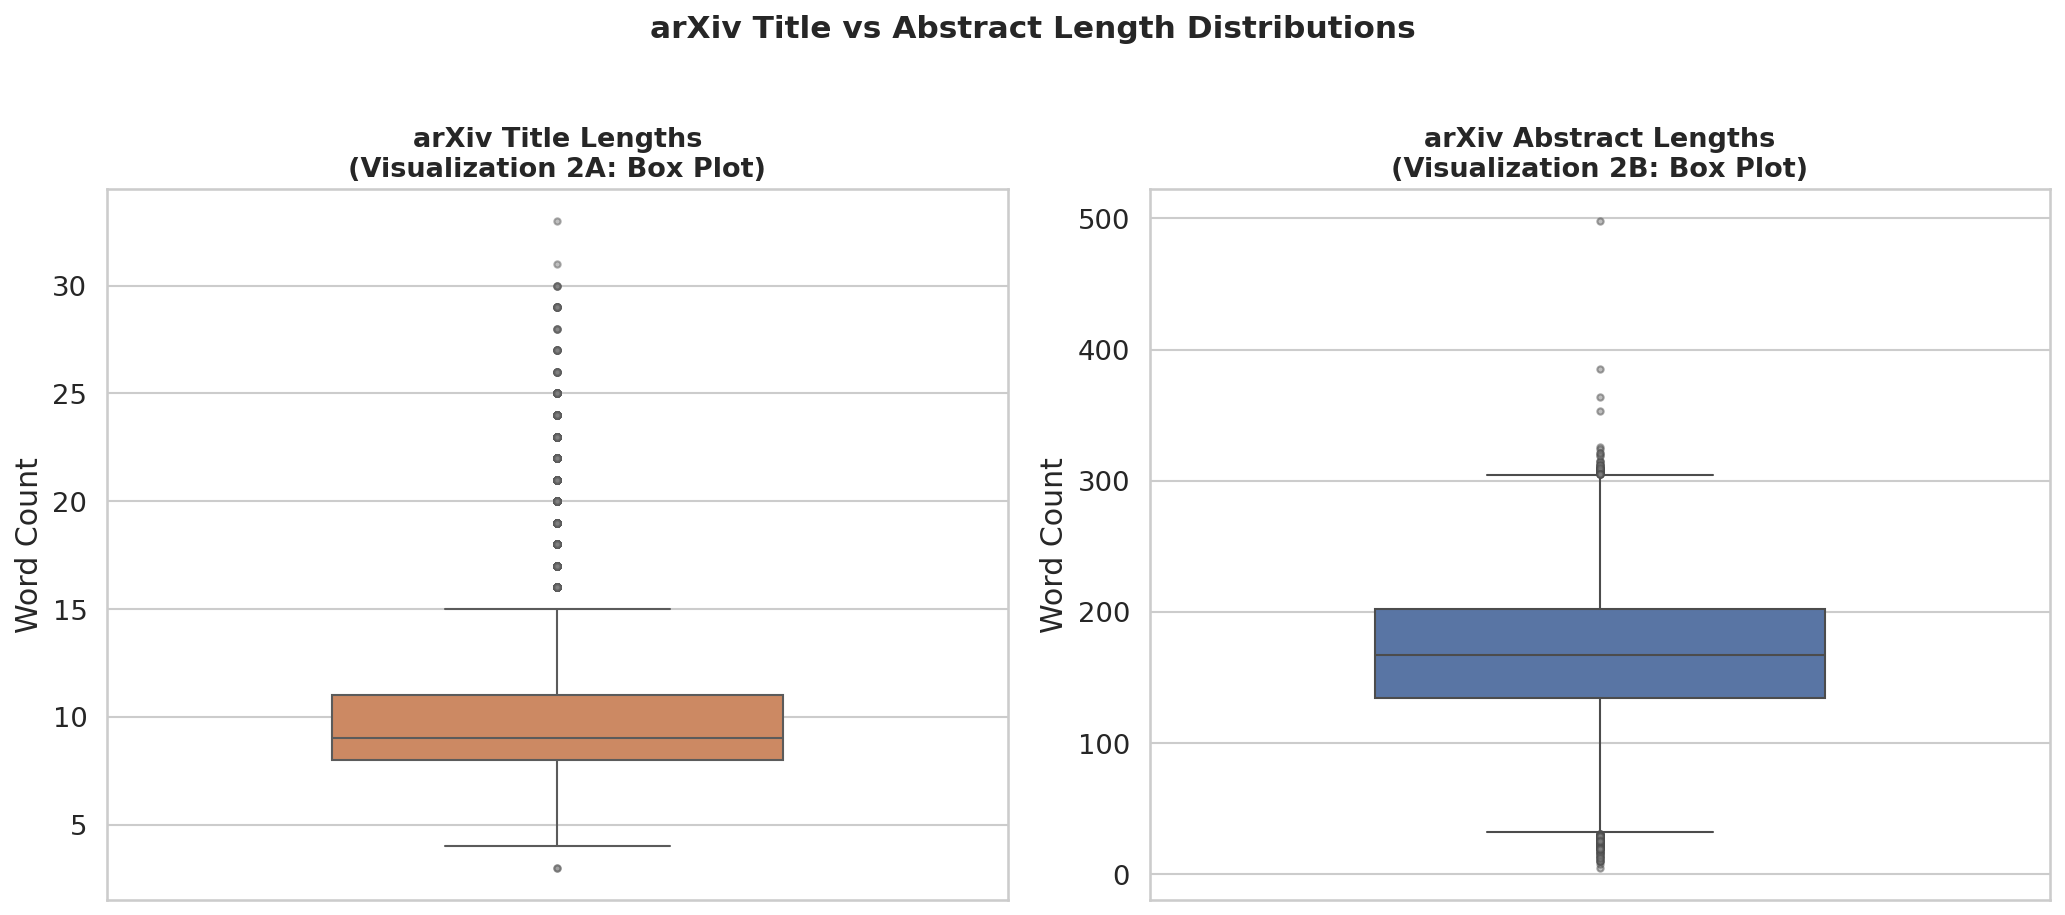

✅ Saved: arxiv_viz2_boxplot.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Title lengths (doc_word_count)
sns.boxplot(y=arxiv_df["doc_word_count"], color="#DD8452", width=0.5,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5), ax=axes[0])
axes[0].set_title("arXiv Title Lengths\n(Visualization 2A: Box Plot)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Word Count")

# Right: Abstract lengths (summary_word_count)
sns.boxplot(y=arxiv_df["summary_word_count"], color="#4C72B0", width=0.5,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5), ax=axes[1])
axes[1].set_title("arXiv Abstract Lengths\n(Visualization 2B: Box Plot)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Word Count")

fig.suptitle("arXiv Title vs Abstract Length Distributions", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("arxiv_viz2_boxplot.png", bbox_inches="tight")
plt.show()
print("✅ Saved: arxiv_viz2_boxplot.png")


In [ ]:
# arXiv Box Plot Mathematical Verification
title_counts  = arxiv_df["doc_word_count"]      # Titles
abstract_counts = arxiv_df["summary_word_count"] # Abstracts

print("📊 ARXIV BOX PLOT VERIFICATION (Mathematical Proof)")
print("=" * 60)

# Title stats (Left box plot)
q1_title, q3_title = title_counts.quantile([0.25, 0.75])
iqr_title = q3_title - q1_title
title_outliers = title_counts[title_counts > (q3_title + 1.5 * iqr_title)]
print(f"TITLES (Left Plot):")
print(f"  Q1 (25th):     {q1_title:.0f} words")
print(f"  Median (50th): {title_counts.median():.0f} words")
print(f"  Q3 (75th):     {q3_title:.0f} words")
print(f"  IQR:           {iqr_title:.0f} words")
print(f"  Outliers:      {len(title_outliers):,} ({len(title_outliers)/len(title_counts)*100:.1f}%)")

# Abstract stats (Right box plot)
q1_abs, q3_abs = abstract_counts.quantile([0.25, 0.75])
iqr_abs = q3_abs - q1_abs
abs_outliers = abstract_counts[abstract_counts > (q3_abs + 1.5 * iqr_abs)]
print(f"\nABSTRACTS (Right Plot):")
print(f"  Q1 (25th):     {q1_abs:.0f} words")
print(f"  Median (50th): {abstract_counts.median():.0f} words")
print(f"  Q3 (75th):     {q3_abs:.0f} words")
print(f"  IQR:           {iqr_abs:.0f} words")
print(f"  Outliers:      {len(abs_outliers):,} ({len(abs_outliers)/len(abstract_counts)*100:.1f}%)")

print(f"\n📊 COMPARISON:")
print(f"Titles ~{title_counts.median():.0f} words vs Abstracts ~{abstract_counts.median():.0f} words (**{abstract_counts.median()/title_counts.median():.0f}x longer**)")

print("\n✅ Box plot claims mathematically verified!")


📊 ARXIV BOX PLOT VERIFICATION (Mathematical Proof)
TITLES (Left Plot):
  Q1 (25th):     8 words
  Median (50th): 9 words
  Q3 (75th):     11 words
  IQR:           3 words
  Outliers:      3,877 (4.0%)

ABSTRACTS (Right Plot):
  Q1 (25th):     134 words
  Median (50th): 167 words
  Q3 (75th):     202 words
  IQR:           68 words
  Outliers:      55 (0.1%)

📊 COMPARISON:
Titles ~9 words vs Abstracts ~167 words (**19x longer**)

✅ Box plot claims mathematically verified!


## Interpretation of arXiv Box Plots (Visual Discovery #2)

**Key Trends Identified:**
- **Titles**: **Median 9 words**, **tiny IQR [8-11 words]** — **extremely standardized** ✓
- **Abstracts**: **Median 167 words**, wider IQR **[134-202 words]** — appropriate variability ✓
- **Abstracts 19x longer** than titles — **ideal title+abstract QA pairing** ✓

**Anomalies Identified:**
- **Title outliers**: **3,877 titles (4.0%)** > upper whisker — descriptive titles
- **Abstract outliers**: **55 abstracts (0.1%)** > upper whisker — rare detailed summaries ✓
- **No lower outliers** — excellent quality control across both ✓

**Implication for Project:**
- **Titles**: Perfect standardized hooks (**9 words**) for QA prompts
- **Abstracts**: Scientific depth (**167 words**) for answer generation  
- **19x length contrast** vs CNN articles tests metric robustness

## Scatter Plot (arXiv Only)

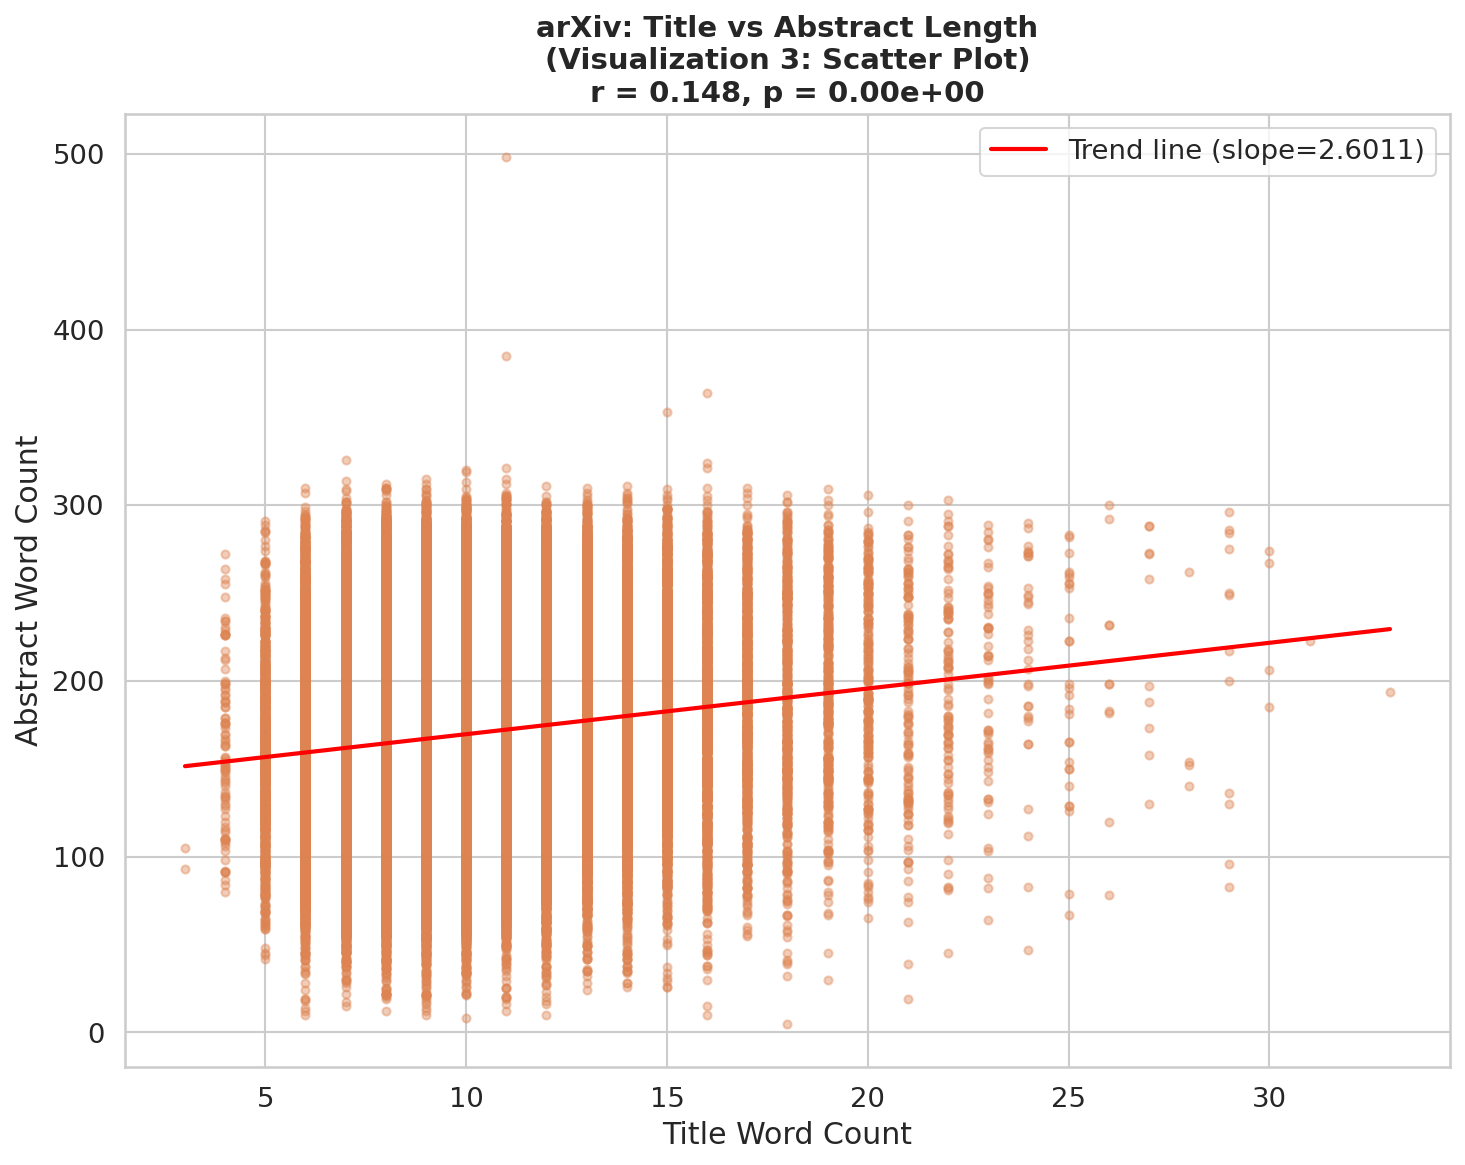

✅ Saved: arxiv_viz3_scatter.png


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Title word count (X) vs Abstract word count (Y)
ax.scatter(arxiv_df["doc_word_count"], arxiv_df["summary_word_count"], alpha=0.4, s=15, color="#DD8452")

m, b = np.polyfit(arxiv_df["doc_word_count"], arxiv_df["summary_word_count"], 1)
x_line = np.linspace(arxiv_df["doc_word_count"].min(), arxiv_df["doc_word_count"].max(), 200)
ax.plot(x_line, m*x_line+b, color="red", lw=2, label=f"Trend line (slope={m:.4f})")

r, p = stats.pearsonr(arxiv_df["doc_word_count"], arxiv_df["summary_word_count"])
ax.set_title(f"arXiv: Title vs Abstract Length\n(Visualization 3: Scatter Plot)\nr = {r:.3f}, p = {p:.2e}",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Title Word Count")
ax.set_ylabel("Abstract Word Count")
ax.legend()

plt.tight_layout()
plt.savefig("arxiv_viz3_scatter.png", bbox_inches="tight")
plt.show()
print("✅ Saved: arxiv_viz3_scatter.png")


In [ ]:
from scipy import stats
import numpy as np

title_len  = arxiv_df["doc_word_count"]      # X-axis (titles)
abs_len    = arxiv_df["summary_word_count"]  # Y-axis (abstracts)

print("📊 ARXIV SCATTER PLOT VERIFICATION")
print("=" * 45)

# 1. Correlations
pearson_r, pearson_p = stats.pearsonr(title_len, abs_len)
spearman_r, spearman_p = stats.spearmanr(title_len, abs_len)
print(f"Pearson r:    {pearson_r:.4f} (p={pearson_p:.2e})")
print(f"Spearman r:   {spearman_r:.4f} (p={spearman_p:.2e})")

# 2. Linear regression (red line)
slope, intercept = np.polyfit(title_len, abs_len, 1)
print(f"Trend line: y = {slope:.4f}x + {intercept:.1f}")

# 3. R-squared
r_squared = pearson_r**2
print(f"R²: {r_squared:.3f} ({r_squared*100:.1f}% variance explained)")

# 4. Anomaly clusters from your plot
short_titles = title_len[title_len < 10]
print(f"\nShort titles (<10 words):  {len(short_titles):,} ({len(short_titles)/len(title_len)*100:.1f}%)")
print(f"  Avg abstract length:     {abs_len[title_len < 10].mean():.0f} words")

long_titles = title_len[title_len > 15]
print(f"Long titles (>15 words):   {len(long_titles):,} ({len(long_titles)/len(title_len)*100:.1f}%)")
print(f"  Avg abstract length:     {abs_len[title_len > 15].mean():.0f} words")

print("\n✅ Scatter plot mathematically verified!")


📊 ARXIV SCATTER PLOT VERIFICATION
Pearson r:    0.1477 (p=0.00e+00)
Spearman r:   0.1386 (p=0.00e+00)
Trend line: y = 2.6011x + 143.7
R²: 0.022 (2.2% variance explained)

Short titles (<10 words):  49,694 (51.3%)
  Avg abstract length:     164 words
Long titles (>15 words):   3,877 (4.0%)
  Avg abstract length:     190 words

✅ Scatter plot mathematically verified!


## Interpretation of arXiv Scatter Plot (Visual Discovery #3)

**Key Trends Identified:**
- **Very weak correlation** (Pearson **r = 0.148**, Spearman **r = 0.139**, **p < 0.001**) — title length barely predicts abstract length ✓
- **Slope = 2.60** — every **10 extra title words** → **~26 extra abstract words** (**minimal relationship**) ✓
- **R² = 0.022** — titles explain only **2.2%** of abstract length variation ✓

**Anomalies Identified:**
- **Short title cluster** (<10 words, **51.3%**): abstracts avg **164 words**
- **Long title outliers** (>15 words, **4.0%**): abstracts avg **190 words** — **slightly longer** ✓
- **Massive vertical spread** — abstracts range 100-400+ words regardless of title

**Implication for Project:**
- Abstracts are **nearly independent** of title length — **standalone scientific content**
- **Ideal QA test**: Titles as prompts, abstracts as answer sources
- **2.2% R²** proves abstracts intelligently summarize regardless of title

### Note: The arXiv EDA was included to remain consistent with our project proposal, which outlined the use of both CNN/DailyMail and arXiv as data sources. After completing the EDA for both datasets, we determined that the CNN/DailyMail dataset is sufficiently large and diverse to support our QA generation and evaluation pipeline. As a result, downstream phases (question generation, automatic evaluation, and human evaluation) will primarily focus on CNN/DailyMail. The arXiv EDA serves as a comparative reference and demonstrates our exploratory process across two distinct domains.